# Gradient notebook

## Gradient in 1D

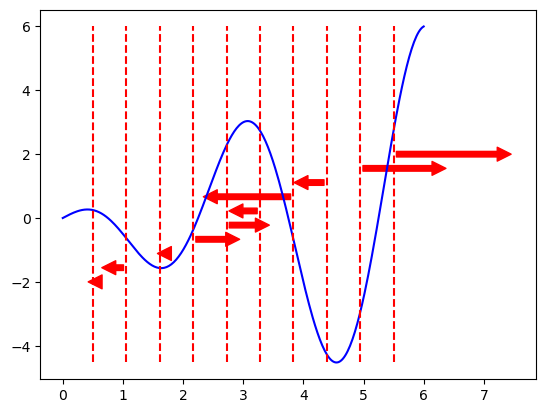

In [28]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

# Define function to plot and its derivative
def f(x):
    return x*np.cos(2*np.pi*x/3)

def grad(x):
    return np.cos(2*np.pi*x/3) - 2*np.pi*x/3*np.sin(2*np.pi*x/3)

# Number of points in the function x axis and the arrow x axis
Npt = 300
Nar = 10

# Function
x_pt = np.linspace(0,6,num = Npt)
fx_pt = f(x_pt)

# Arrows
x_ar = np.linspace(0.5, 5.5, num=Nar)
const = np.max(grad(x_ar))
y_off = np.linspace(-2, 2, num=Nar)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_pt, fx_pt, color='b')

for x, y in zip(x_ar, y_off):
    arrow = mpatches.FancyArrowPatch((x,y), (x+2*grad(x)/const, y), mutation_scale=20, color='r')
    ax.add_patch(arrow)
    ax.plot([x, x], [np.min(fx_pt), np.max(fx_pt)], color='r', linestyle='dashed')


## Gradient in 2D

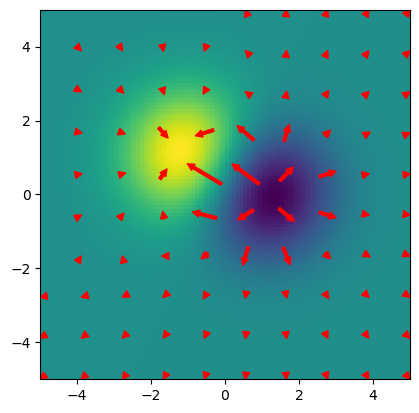

In [29]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches


dx = 0.1
dy = 0.1
X, Y = np.meshgrid(np.arange(-5,5,dx), np.arange(-5, 5, dy))

def T(X, Y):
    return 4*np.exp(-(np.pow(X+1,2)+np.pow(Y-1,2))/3) - 4*np.exp(-(np.pow(X-1,2)+np.pow(Y,2))/3)

def gradT(X, Y):
      g1 = np.exp(-((X+1)**2 + (Y-1)**2)/2)
      g2 = np.exp(-((X-1)**2 + Y**2)/3)
      dTdX = -(8/3)*(X+1)*g1 + (8/3)*(X-1)*g2
      dTdY = -(8/3)*(Y-1)*g1 + (8/3)*Y*g2
      return dTdX, dTdY

Txy = T(X, Y)

N_ar = 10
X_ar, Y_ar = np.meshgrid(np.linspace(-5,5,N_ar), np.linspace(-5, 5, N_ar))
dTdX_ar, dTdY_ar = gradT(X_ar, Y_ar)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(Txy, extent = [-5, 5, -5, 5], origin='lower')

scale=0.4
for i in range(N_ar):
    for j in range(N_ar):
        x = X_ar[i,j]
        y = Y_ar[i,j]
        dx = dTdX_ar[i,j]*scale
        dy = dTdY_ar[i,j]*scale
        arrow = mpatches.FancyArrowPatch((x-dx/2,y-dy/2), (x+dx/2, y+dy/2), mutation_scale=10, color='r')
        ax.add_patch(arrow)


## Gadrient vs equipotential lines

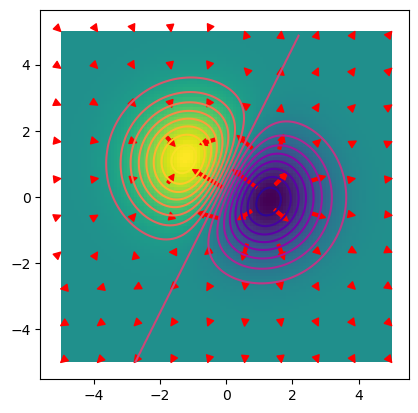

In [33]:
import numpy as np 
import matplotlib.pyplot as plt 

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(Txy, extent = [-5, 5, -5, 5], origin='lower')

scale=0.4
for i in range(N_ar):
    for j in range(N_ar):
        x = X_ar[i,j]
        y = Y_ar[i,j]
        dx = dTdX_ar[i,j]*scale
        dy = dTdY_ar[i,j]*scale
        arrow = mpatches.FancyArrowPatch((x-dx/2,y-dy/2), (x+dx/2, y+dy/2), mutation_scale=10, color='r')
        ax.add_patch(arrow)

ax.contour(X, Y, Txy, levels=20, cmap='plasma')

